# Dell best_of run

In [2]:
import warnings
from statsmodels.tools.sm_exceptions import ConvergenceWarning
# Suppress common statsmodels warnings
warnings.filterwarnings("ignore", category=UserWarning)
warnings.filterwarnings("ignore", category=FutureWarning)
warnings.filterwarnings("ignore", category=ConvergenceWarning)
warnings.filterwarnings("ignore", message="No supported index is available")
warnings.filterwarnings("ignore", message="A date index has been provided, but it has no associated frequency")

In [3]:
#load libraries
# Core libraries
import os
os.environ['PYTHONHASHSEED'] = '22'
import random
import time
import string
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Statistical and time series analysis
from scipy.stats import spearmanr, pearsonr
from scipy.stats import pearsonr
from statsmodels.tsa.stattools import adfuller, grangercausalitytests
from statsmodels.tsa.seasonal import seasonal_decompose
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf
from statsmodels.tsa.statespace.sarimax import SARIMAX

# Forecasting
from pmdarima import auto_arima

# Machine learning
from sklearn.metrics import mean_squared_error, mean_absolute_error
from sklearn.preprocessing import MinMaxScaler
from xgboost import XGBRegressor

# Deep learning (LSTM)
import tensorflow as tf
import keras_tuner
from tensorflow.keras import optimizers
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense, Dropout, LeakyReLU
from tensorflow.keras.callbacks import EarlyStopping
from keras_tuner.tuners import RandomSearch
from keras_tuner import HyperModel

# loading data
import yfinance as yf

#!pip install xgboost
#!pip install keras-tuner --quiet
#!pip install pmdarima

#preventinf memory full error
import gc
from keras import backend as K

In [4]:
#setting random seeed
seed = 22
random.seed(seed)
np.random.seed(seed)
tf.random.set_seed(seed)

## Pulling in data

In [6]:
# data doenloaded via google cloab instead
# uploading here

# Load the full combined file
df = pd.read_csv("dell_exo_data_covid/dell_exo_variables_combined_2020_2021.csv", skiprows = 1, index_col=0, parse_dates=True, date_format="%Y-%m-%d")

# Drop the first row (which is still the leftover 'Date' label)
df = df[df.index != "Date"].copy()

# Convert all columns to numeric (force errors to NaN)
df = df.apply(pd.to_numeric, errors="coerce")

# Check structure
print(df.info())
print(df.head())
print("\nMissing values:\n", df.isna().sum())

<class 'pandas.core.frame.DataFrame'>
Index: 313 entries, 2020-01-02 to 2021-03-30
Data columns (total 12 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   DELL      313 non-null    float64
 1   SMH       313 non-null    float64
 2   ^IXIC     313 non-null    float64
 3   XLK       313 non-null    float64
 4   HG=F      313 non-null    float64
 5   CL=F      313 non-null    float64
 6   DX-Y.NYB  313 non-null    float64
 7   ^TNX      313 non-null    float64
 8   ^VIX      313 non-null    float64
 9   XLY       313 non-null    float64
 10  XLI       313 non-null    float64
 11  IYT       313 non-null    float64
dtypes: float64(12)
memory usage: 31.8+ KB
None
                 DELL        SMH        ^IXIC        XLK    HG=F       CL=F  \
Ticker                                                                        
2020-01-02  24.481901  69.920441  9092.190430  88.947220  2.8330  61.180000   
2020-01-03  23.676603  68.775078  9020.769531  87.947

Function for evaluating complex LSTM model

In [8]:
def evaluate_lstm_model(
    df,
    model_fn,
    forecast_horizons=[1, 3, 7],
    train_end="2020-12-31",
    test_start="2021-01-01",
    window_size=30,
    epochs=20,
    output_csv_path="lstm_metrics_dell.csv",
    plot=True,
    callbacks=None
):
    df = df.copy()
    df.index = pd.to_datetime(df.index)
    df = df.asfreq('B')
    series = df['DELL'].dropna().to_frame()

    scaler = MinMaxScaler()
    series_scaled = scaler.fit_transform(series)

    split_train = series.index <= train_end
    split_test = series.index >= test_start

    all_metrics = []

    for h in forecast_horizons:
        preds, actuals, dates = [], [], []

        for i in range(window_size, len(series_scaled) - h):
            if not split_test[i + h]:
                continue

            X = series_scaled[i - window_size:i].reshape(1, window_size, 1)
            y = series_scaled[i + h][0]

            X_train_full, y_train_full = [], []
            for j in range(window_size, i):
                X_train_full.append(series_scaled[j - window_size:j])
                y_train_full.append(series_scaled[j][0])
            X_train_full = np.array(X_train_full)
            y_train_full = np.array(y_train_full)

            model = model_fn((window_size, 1))
            model.fit(X_train_full, y_train_full, epochs=epochs, verbose=0, callbacks=callbacks)

            pred_scaled = model.predict(X)[0][0]
            pred = scaler.inverse_transform([[pred_scaled]])[0][0]
            actual = series.iloc[i + h][0]

            preds.append(pred)
            actuals.append(actual)
            dates.append(series.index[i + h])

        if preds:
            rmse = np.sqrt(mean_squared_error(actuals, preds))
            mae = mean_absolute_error(actuals, preds)
            mape = mean_absolute_percentage_error(actuals, preds)
            print(f"Horizon {h}: RMSE={rmse:.2f}, MAE={mae:.2f}, MAPE={mape:.2f}")

            all_metrics.append({
                "model": model_fn.__name__,
                "horizon": h,
                "rmse": rmse,
                "mae": mae,
                "mape": mape
            })

            if plot:
                plt.figure(figsize=(10, 4))
                plt.plot(dates, actuals, label="Actual")
                plt.plot(dates, preds, label="Forecast")
                plt.title(f"{model_fn.__name__} - {h}-Day Horizon")
                plt.xlabel("Date")
                plt.ylabel("DELL Price")
                plt.legend()
                plt.tight_layout()
                plt.show()

    df_metrics = pd.DataFrame(all_metrics)
    df_metrics.to_csv(output_csv_path, index=False)
    print(f"\n Saved metrics to {output_csv_path}")
    return df_metrics

In [9]:
#defining hypermodel for keras tuner
class LSTMHyperModel(HyperModel):
    def __init__(self, input_shape):
        self.input_shape = input_shape

    def build(self, hp):
        model = Sequential()

        # First LSTM layer
        activation_1 = hp.Choice("activation_1", ["relu", "tanh", "leaky_relu"])
        units_1 = hp.Int("units_1", min_value=16, max_value=128, step=16)
        return_seq = hp.Boolean("return_seq_1")

        if activation_1 == "leaky_relu":
            model.add(LSTM(units_1, activation=None, return_sequences=return_seq, input_shape=self.input_shape))
            model.add(LeakyReLU(alpha=hp.Float("leaky_relu_alpha_1", 0.01, 0.3, step=0.05)))
        else:
            model.add(LSTM(units_1, activation=activation_1, return_sequences=return_seq, input_shape=self.input_shape))

        # Optional second LSTM layer — only if first returns sequences
        if return_seq and hp.Boolean("add_second_lstm"):
            model.add(Dropout(hp.Float("dropout_1", 0.0, 0.4, step=0.1)))
            units_2 = hp.Int("units_2", min_value=16, max_value=64, step=16)
            activation_2 = hp.Choice("activation_2", ["relu", "tanh", "leaky_relu"])
            if activation_2 == "leaky_relu":
                model.add(LSTM(units_2, activation=None))
                model.add(LeakyReLU(alpha=hp.Float("leaky_relu_alpha_2", 0.01, 0.3, step=0.05)))
            else:
                model.add(LSTM(units_2, activation=activation_2))

        # Optional final dropout
        if hp.Boolean("add_final_dropout"):
            model.add(Dropout(hp.Float("final_dropout", 0.0, 0.3, step=0.1)))

        # Output layer
        model.add(Dense(1))  # Avoided activation=None/linear choice to keep tuner stable

        # Optimizer
        optimizer_name = hp.Choice("optimizer", ["adam", "rmsprop"])
        learning_rate = hp.Float("learning_rate", 1e-5, 1e-2, sampling="log")
        optimizer = optimizers.Adam(learning_rate) if optimizer_name == "adam" else optimizers.RMSprop(learning_rate)

        model.compile(optimizer=optimizer, loss="mse", metrics=["mae"])
        return model

In [10]:
# window size
window_size = 30
input_shape = (window_size, 1)
# scaled DELL series
df = df.copy()
df.index = pd.to_datetime(df.index)
df = df.asfreq("B")
series = df["DELL"].dropna().to_frame()

scaler = MinMaxScaler()
series_scaled = scaler.fit_transform(series)

#training sequences
X_train, y_train = [], []
for i in range(window_size, int(len(series_scaled) * 0.8)):
    X_train.append(series_scaled[i - window_size:i])
    y_train.append(series_scaled[i][0])

X_train = np.array(X_train)
y_train = np.array(y_train)

In [11]:
# Setup tuner
tuner = RandomSearch(
    LSTMHyperModel(input_shape=(window_size, 1)),
    objective="val_loss",
    max_trials=20,
    executions_per_trial=1,
    directory="lstm_tuning",
    project_name="baseline_tune",
    seed=seed #setting random seed
)

# Run tuning
early_stop = EarlyStopping(monitor="val_loss", patience=3, restore_best_weights=True)
tuner.search(X_train, y_train, validation_split=0.2, epochs=20, callbacks=[early_stop])

# Get best model + hyperparameters
best_hp = tuner.get_best_hyperparameters(1)[0]
best_model_complex = tuner.hypermodel.build(best_hp)

# Display best config
print("\n Best Hyperparameter Configuration:")
for k, v in best_hp.values.items():
    print(f"{k}: {v}")

Reloading Tuner from lstm_tuning\baseline_tune\tuner0.json

 Best Hyperparameter Configuration:
activation_1: tanh
units_1: 64
return_seq_1: False
add_second_lstm: False
add_final_dropout: True
output_activation: linear
optimizer: adam
learning_rate: 0.006571970090025509
dropout_1: 0.4
units_2: 64
activation_2: relu
leaky_relu_alpha_1: 0.11
final_dropout: 0.2


1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 39ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 35ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 32ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 30ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 34ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 37ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 32ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 33ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 34ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 31ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 51ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 57ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 38ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 56ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 57ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 59ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 37ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 44ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 38ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 56ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 47ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 38ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 40ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 40ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 49ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 47ms/step
1/1 ━━━━━━━━

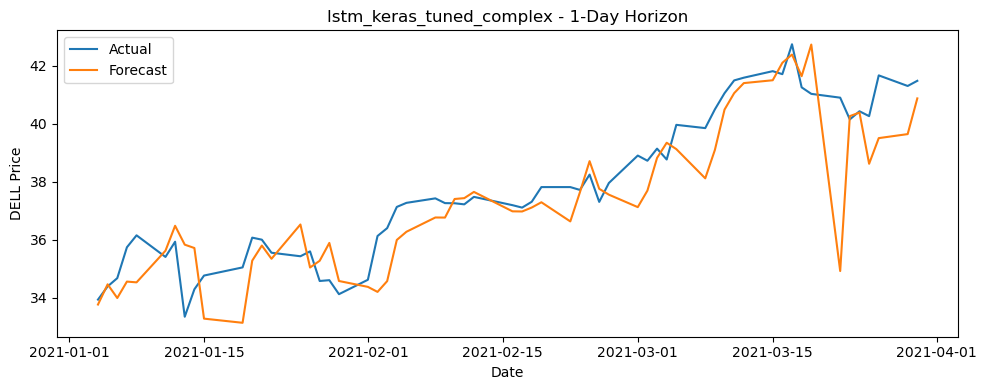

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 53ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 69ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 32ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 39ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 33ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 49ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 32ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 44ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 36ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 36ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 33ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 48ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 43ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 38ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 47ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 68ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 32ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 37ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 49ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 45ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 45ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 28ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 36ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 45ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 30ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 55ms/step
1/1 ━━━━━━━━

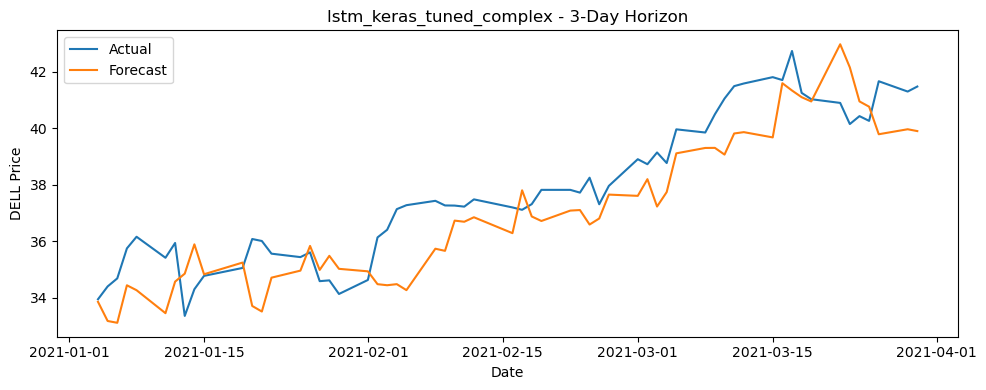

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 35ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 34ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 43ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 33ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 26ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 28ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 31ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 47ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 30ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 43ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 38ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 28ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 50ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 34ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 37ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 41ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 34ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 35ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 36ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 38ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 36ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 32ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 29ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 27ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 28ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 74ms/step
1/1 ━━━━━━━━

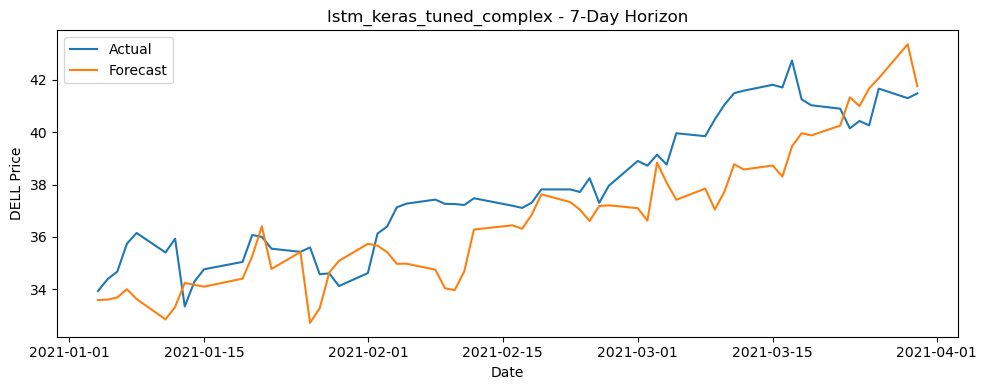


 Saved metrics to lstm_keras_tuned_metrics_dell.csv


,model,horizon,rmse,mae,mape
0,lstm_keras_tuned_complex,1,1.267615,0.878900,2.325782
1,lstm_keras_tuned_complex,3,1.369450,1.157464,3.062220
2,lstm_keras_tuned_complex,7,1.796157,1.457771,3.806022


In [20]:
def mean_absolute_percentage_error(y_true, y_pred):
    y_true, y_pred = np.array(y_true), np.array(y_pred)
    mask = y_true != 0
    return np.mean(np.abs((y_true[mask] - y_pred[mask]) / y_true[mask])) * 100
#wrapper
def lstm_keras_tuned_complex(input_shape):
    return best_model_complex
#evaluate
evaluate_lstm_model(
    df=df,
    model_fn=lstm_keras_tuned_complex,
    forecast_horizons=[1, 3, 7],
    output_csv_path="lstm_keras_tuned_metrics_dell.csv",
    callbacks=[early_stop]
)

In [21]:
#saving best model for use with exo variables later
best_hp = tuner.get_best_hyperparameters(1)[0]

def best_model_fn(input_shape):
    model = LSTMHyperModel(input_shape).build(best_hp)
    return model

In [22]:
def evaluate_lstm_model_with_exo(
    df,
    exo_var=None,
    model_fn=None,
    forecast_horizons=[1, 3, 7],
    train_end="2020-12-31",
    test_start="2021-01-01",
    window_size=30,
    epochs=10,
    output_csv_path="metrics_dell.csv",
    plot=True,  
    callbacks=None
):
    df = df.copy()
    df.index = pd.to_datetime(df.index)
    df = df.asfreq("B")

    features = ["DELL"] + ([exo_var] if isinstance(exo_var, str) else exo_var or [])
    df = df[features].dropna()

    scaler = MinMaxScaler()
    data_scaled = scaler.fit_transform(df)

    split_train = df.index <= train_end
    split_test = df.index >= test_start

    all_metrics = []

    for h in forecast_horizons:
        preds, actuals, dates = [], [], []

        for i in range(window_size, len(data_scaled) - h):
            if not split_test[i + h]:
                continue

            # Build training set once per step
            X_train_full, y_train_full = [], []
            for j in range(window_size, i):
                X_train_full.append(data_scaled[j - window_size:j])
                y_train_full.append(data_scaled[j][0])

            X_train_full = np.array(X_train_full, dtype=np.float32)
            y_train_full = np.array(y_train_full, dtype=np.float32)

            X = data_scaled[i - window_size:i].reshape(1, window_size, len(features))

            # Create, fit, and predict
            model = model_fn((window_size, len(features)))
            model.fit(X_train_full, y_train_full, epochs=epochs, verbose=0, callbacks=callbacks)

            pred_scaled = model.predict(X)[0][0]
            pred = scaler.inverse_transform([[pred_scaled] + [0] * (len(features) - 1)])[0][0]
            actual = df.iloc[i + h]["DELL"]

            preds.append(pred)
            actuals.append(actual)
            dates.append(df.index[i + h])

            # CLEANUP
            del model, X_train_full, y_train_full, X
            K.clear_session()
            gc.collect()

        # Compute metrics
        if preds:
            rmse = np.sqrt(mean_squared_error(actuals, preds))
            mae = mean_absolute_error(actuals, preds)
            mape = mean_absolute_percentage_error(actuals, preds)
            print(f"Exo: {exo_var or 'None'} - Horizon {h} -> RMSE={rmse:.2f}, MAE={mae:.2f}, MAPE={mape:.2f}")

            all_metrics.append({
                "model": model_fn.__name__,
                "exo_var": exo_var or "None",
                "horizon": h,
                "rmse": rmse,
                "mae": mae,
                "mape": mape
            })

            if plot:
                plt.figure(figsize=(10, 4))
                plt.plot(dates, actuals, label="Actual")
                plt.plot(dates, preds, label="Forecast")
                plt.title(f"{exo_var or 'No Exo'} - {h}-Day Horizon")
                plt.xlabel("Date")
                plt.ylabel("DELL Price")
                plt.legend()
                plt.tight_layout()
                plt.show()

    # Save results
    df_metrics = pd.DataFrame(all_metrics)

    if os.path.exists(output_csv_path):
        existing = pd.read_csv(output_csv_path)
        df_metrics = pd.concat([existing, df_metrics], ignore_index=True)

    df_metrics.to_csv(output_csv_path, index=False)
    print(f"\nSaved metrics to {output_csv_path}")
    return df_metrics

## Best of run

In [24]:
# best from each category identified - defining list to use in model
best_exo_by_horizon = {
    1: ["SMH", "HG=F", "XLI"],
    3: ["SMH", "HG=F", "^VIX"],
    7: ["SMH", "HG=F", "DX-Y.NYB"]
}

In [27]:
grouped_exo_vars = {
    "sectoral": ["SMH", "^IXIC", "XLK"],
    "macroeconomic": ["DX-Y.NYB", "^TNX", "^VIX", "XLY", "XLI"],
    "supply_chain_and_commodities": ["HG=F", "CL=F", "IYT"]
}

In [31]:
df.head()

,DELL,SMH,^IXIC,XLK,HG=F,CL=F,DX-Y.NYB,^TNX,^VIX,XLY,XLI,IYT
Ticker,,,,,,,,,,,,
2020-01-02,24.481901,69.920441,9092.190430,88.947220,2.8330,61.180000,96.849998,1.882,12.47,121.004021,75.932228,46.198429
2020-01-03,23.676603,68.775078,9020.769531,87.947159,2.7985,63.049999,96.839996,1.788,14.02,119.974274,75.785889,45.879711
2020-01-06,23.915379,68.040489,9071.469727,88.156693,2.8005,63.270000,96.669998,1.811,13.85,120.307991,75.813316,45.605534
2020-01-07,23.316090,69.176201,9068.580078,88.118584,2.8040,62.700001,96.980003,1.827,13.79,120.117302,75.657822,45.764900
2020-01-08,23.409731,69.292183,9129.240234,89.061523,2.8190,59.610001,97.300003,1.874,13.45,120.479614,75.913940,46.142181



 Evaluating best exogenous variables for horizon 1 with variables: SMH, HG=F, XLI
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 159ms/step

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 159ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 153ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 151ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 145ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 156ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 143ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 171ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 145ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 158ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 154ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 148ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 144ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 143ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 154ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 163ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 144ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 149ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 153ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 147ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 162ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 172ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 138ms/step
1/1 ━━━━━━━━━━━━━━━

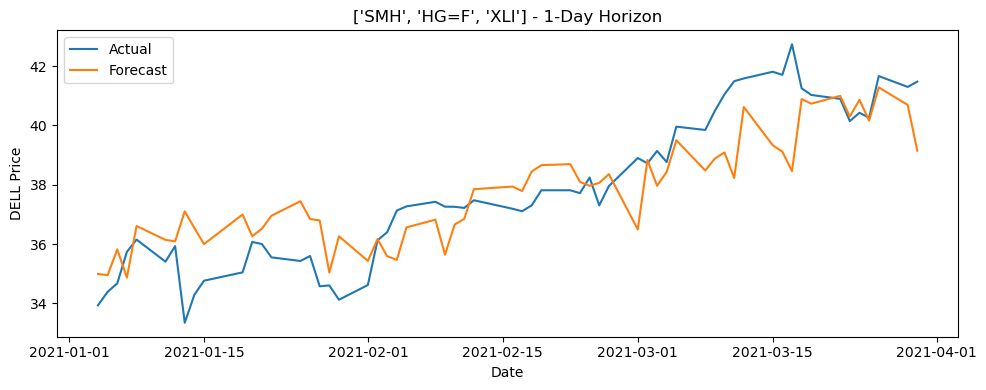


Saved metrics to metrics_lstm_bestof_horizon_1_dell.csv

 Evaluating best exogenous variables for horizon 1 with variables: SMH, HG=F, XLI
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 146ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 142ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 133ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 147ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 159ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 142ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 146ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 142ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 142ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 150ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 143ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 143ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 137ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 142ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 144ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 144ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 189ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 142ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 148ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 145ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 143ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 144ms/step
1/

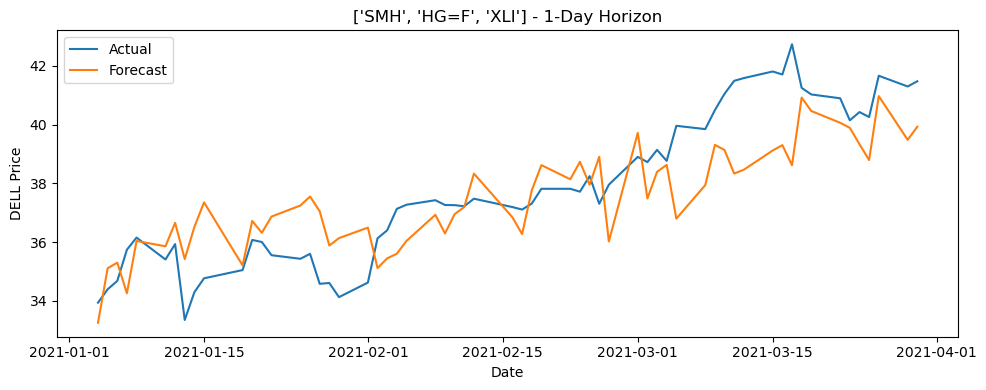


Saved metrics to metrics_lstm_bestof_horizon_1_dell.csv

 Evaluating best exogenous variables for horizon 1 with variables: SMH, HG=F, XLI
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 155ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 135ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 139ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 145ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 149ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 146ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 154ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 145ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 148ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 146ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 170ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 173ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 152ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 161ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 150ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 158ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 159ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 142ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 157ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 170ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 175ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 281ms/step
1/

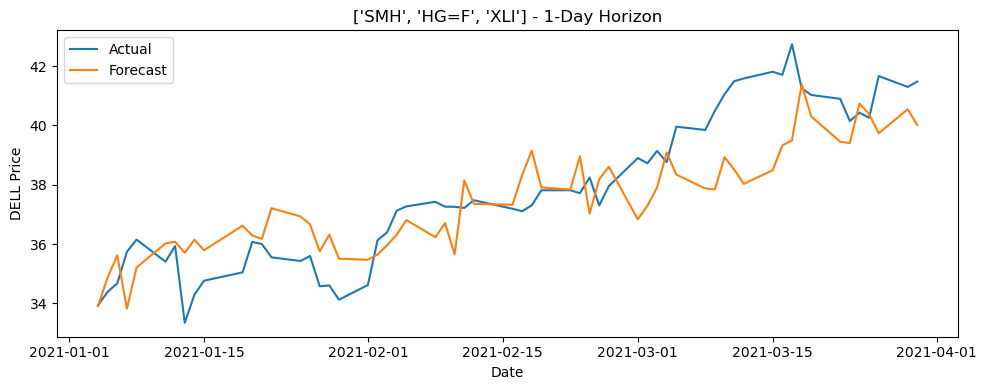


Saved metrics to metrics_lstm_bestof_horizon_1_dell.csv


In [33]:
#loop for evauating best of each categories variables combined
for group_name, var_list in grouped_exo_vars.items():
    print(f"\n Evaluating best exogenous variables for horizon 1 with variables: SMH, HG=F, XLI")
    
    evaluate_lstm_model_with_exo(
        df=df.copy(),
        exo_var=["SMH", "HG=F", "XLI"],  # List of multiple variables
        model_fn=best_model_fn,
        forecast_horizons=[1], #trying one horizon at a time to deal with memory error
        output_csv_path=f"metrics_lstm_bestof_horizon_1_dell.csv",
        callbacks=[early_stop]
    )


 Evaluating best exogenous variables for horizon 3 with variables: SMH, HG=F, ^VIX
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 140ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 154ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 147ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 157ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 141ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 228ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 235ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 160ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 150ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 147ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 149ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 164ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 157ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 178ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 151ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 141ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 154ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 145ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 145ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 148ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 154ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 152ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 156ms/step
1/1 ━━━━━━━━━━━━━━━

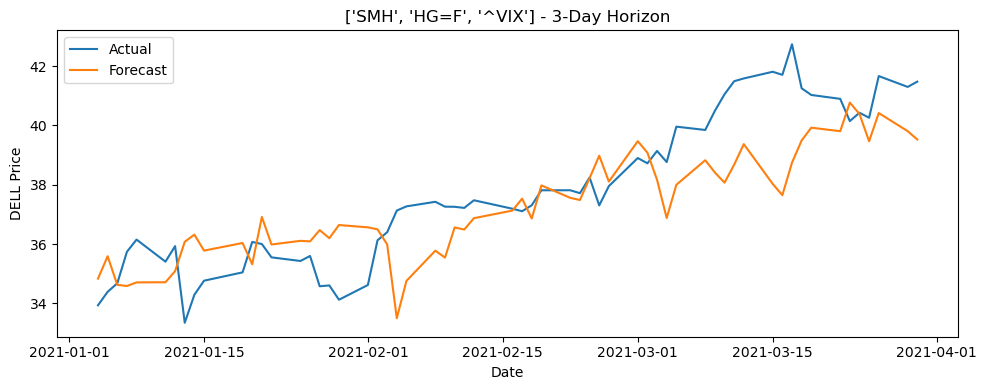


Saved metrics to metrics_lstm_bestof_horizon_3_dell.csv

 Evaluating best exogenous variables for horizon 3 with variables: SMH, HG=F, ^VIX
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 139ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 161ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 152ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 142ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 150ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 157ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 149ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 155ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 160ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 229ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 145ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 155ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 144ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 154ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 165ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 161ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 146ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 156ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 161ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 140ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 153ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 141ms/step
1

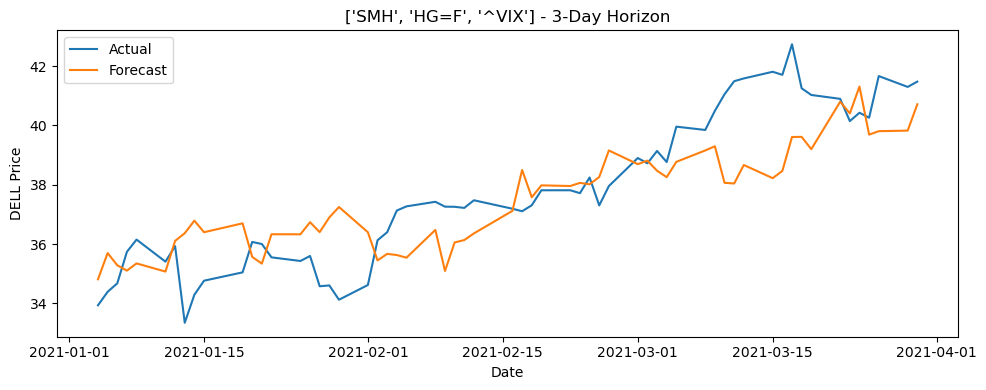


Saved metrics to metrics_lstm_bestof_horizon_3_dell.csv

 Evaluating best exogenous variables for horizon 3 with variables: SMH, HG=F, ^VIX
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 157ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 144ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 155ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 155ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 144ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 226ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 219ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 160ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 133ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 152ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 161ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 158ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 149ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 190ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 142ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 150ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 152ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 154ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 146ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 149ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 146ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 141ms/step
1

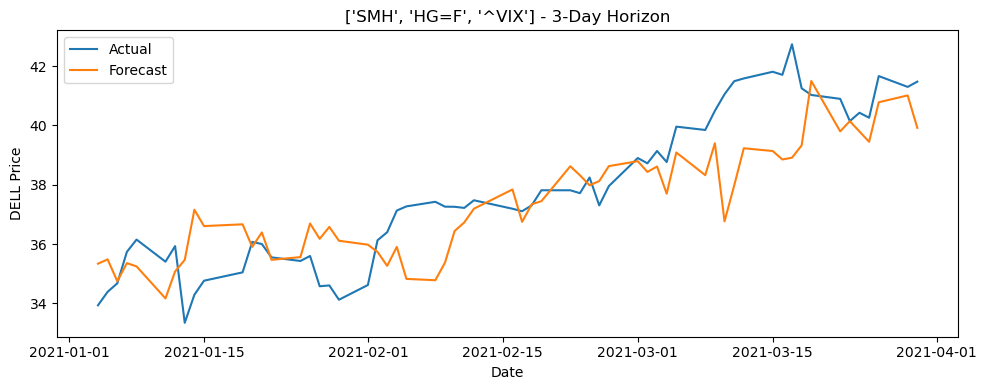


Saved metrics to metrics_lstm_bestof_horizon_3_dell.csv


In [34]:
#horizon 3
for group_name, var_list in grouped_exo_vars.items():
    print(f"\n Evaluating best exogenous variables for horizon 3 with variables: SMH, HG=F, ^VIX")
    
    evaluate_lstm_model_with_exo(
        df=df.copy(),
        exo_var=["SMH", "HG=F", "^VIX"],  # List of multiple variables
        model_fn=best_model_fn,
        forecast_horizons=[3], #trying one horizon at a time to deal with memory error
        output_csv_path=f"metrics_lstm_bestof_horizon_3_dell.csv",
        callbacks=[early_stop]
    )


 Evaluating best exogenous variables for horizon 7 with variables: SMH, HG=F, DX-Y.NYB
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 144ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 156ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 168ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 142ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 161ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 161ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 235ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 159ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 147ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 148ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 155ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 155ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 153ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 257ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 185ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 156ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 155ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 162ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 165ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 149ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 150ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 155ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 148ms/step
1/1 ━━━━━━━━━━━

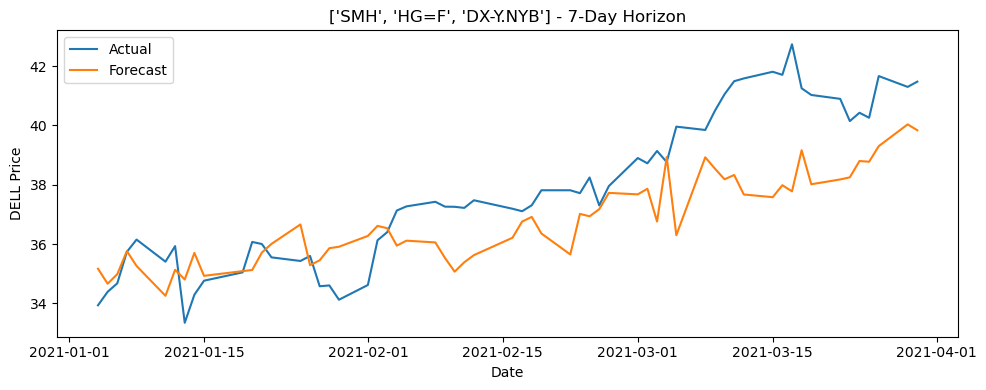


Saved metrics to metrics_lstm_bestof_horizon_7_dell.csv

 Evaluating best exogenous variables for horizon 7 with variables: SMH, HG=F, DX-Y.NYB
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 226ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 159ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 146ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 166ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 159ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 151ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 149ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 150ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 182ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 161ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 144ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 159ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 137ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 153ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 154ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 190ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 156ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 152ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 142ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 149ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 181ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 145ms/st

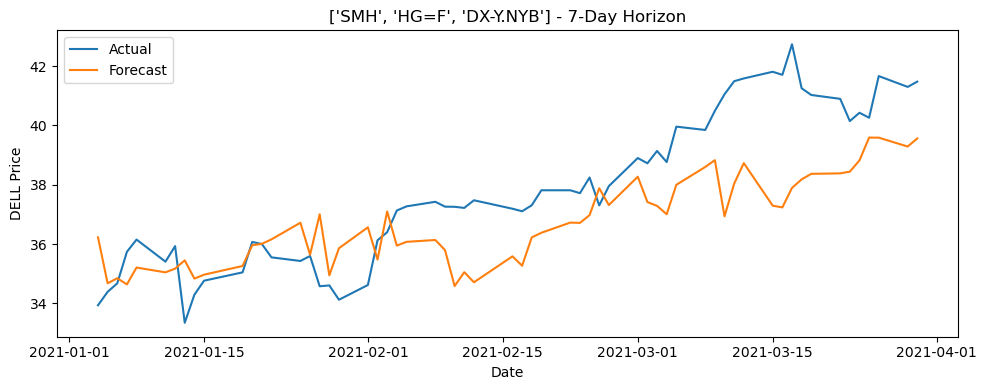


Saved metrics to metrics_lstm_bestof_horizon_7_dell.csv

 Evaluating best exogenous variables for horizon 7 with variables: SMH, HG=F, DX-Y.NYB
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 143ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 144ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 148ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 145ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 160ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 142ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 146ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 160ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 149ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 138ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 137ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 155ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 224ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 155ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 161ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 141ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 141ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 146ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 145ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 147ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 161ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 139ms/st

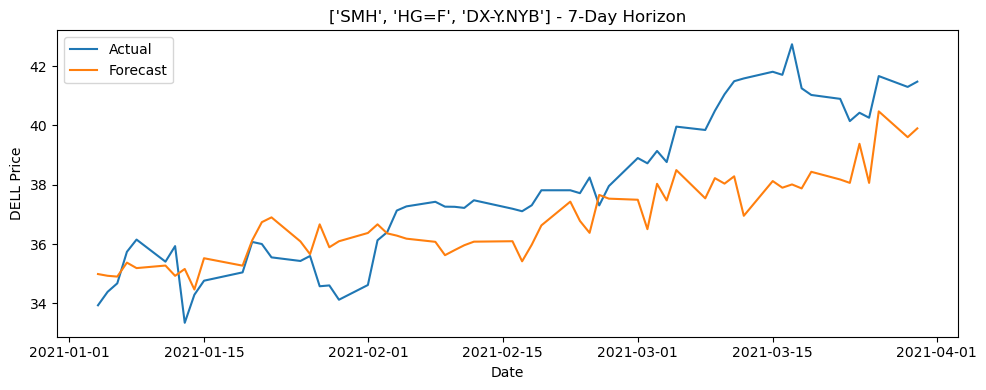


Saved metrics to metrics_lstm_bestof_horizon_7_dell.csv


In [35]:
for group_name, var_list in grouped_exo_vars.items():
    print(f"\n Evaluating best exogenous variables for horizon 7 with variables: SMH, HG=F, DX-Y.NYB")
    
    evaluate_lstm_model_with_exo(
        df=df.copy(),
        exo_var=["SMH", "HG=F", "DX-Y.NYB"],  # List of multiple variables
        model_fn=best_model_fn,
        forecast_horizons=[7], #trying one horizon at a time to deal with memory error
        output_csv_path=f"metrics_lstm_bestof_horizon_7_dell.csv",
        callbacks=[early_stop]
    )